# Event Analysis

Per-event historical analysis and projection, driven by **real World Athletics
season toplists** (`data/processed/toplists_clean.csv`, 2001-2026, men's senior
outdoor).

This one notebook replaces the nine near-identical per-event notebooks that used
to live here. Set `EVENT` in the parameter cell below, or run it under papermill
with `-p EVENT 5000m`.

## 0. Parameters

In [1]:
# Parameters (papermill-compatible)
EVENT = "Marathon"

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.analysis_engine import AnalysisEngine
from src.config import BIOLOGICAL_FLOORS, PROJECTION_TARGET_YEAR, REAL_WR
from src.forecaster import TrackForecaster

sns.set_theme(style="whitegrid")
S = TrackForecaster.seconds_to_str

## 1. Load the data

No `sys.path` hack: the package is installed (`poetry install`), so `src` imports
like any other module regardless of the kernel's working directory.

In [3]:
DATA = "../data/processed/toplists_clean.csv"

clean_df = pd.read_csv(DATA)
clean_df = clean_df[clean_df["event"] == EVENT]
assert not clean_df.empty, f"No rows for {EVENT}; run `trackflation scrape` first."

engine = AnalysisEngine(clean_df)
stats_df = engine.get_yearly_stats()

FIRST_YEAR = int(stats_df["year"].min())
LAST_YEAR = int(stats_df["year"].max())
SPAN = f"{FIRST_YEAR}-{LAST_YEAR}"
print(f"{EVENT}: {len(clean_df)} marks across {len(stats_df)} seasons ({SPAN})")
stats_df.tail()

Marathon: 2600 marks across 26 seasons (2001-2026)


,year,best,top_10_avg,median,count
21,2022,7269.0,7409.0,7568.5,100
22,2023,7235.0,7382.0,7538.5,100
23,2024,7325.0,7381.2,7559.0,100
24,2025,7336.0,7401.7,7546.0,100
25,2026,7170.0,7333.6,7527.5,100


## 2. Exploratory analysis

Every title below is generated from the data, so the labels cannot drift away from
the years actually plotted.

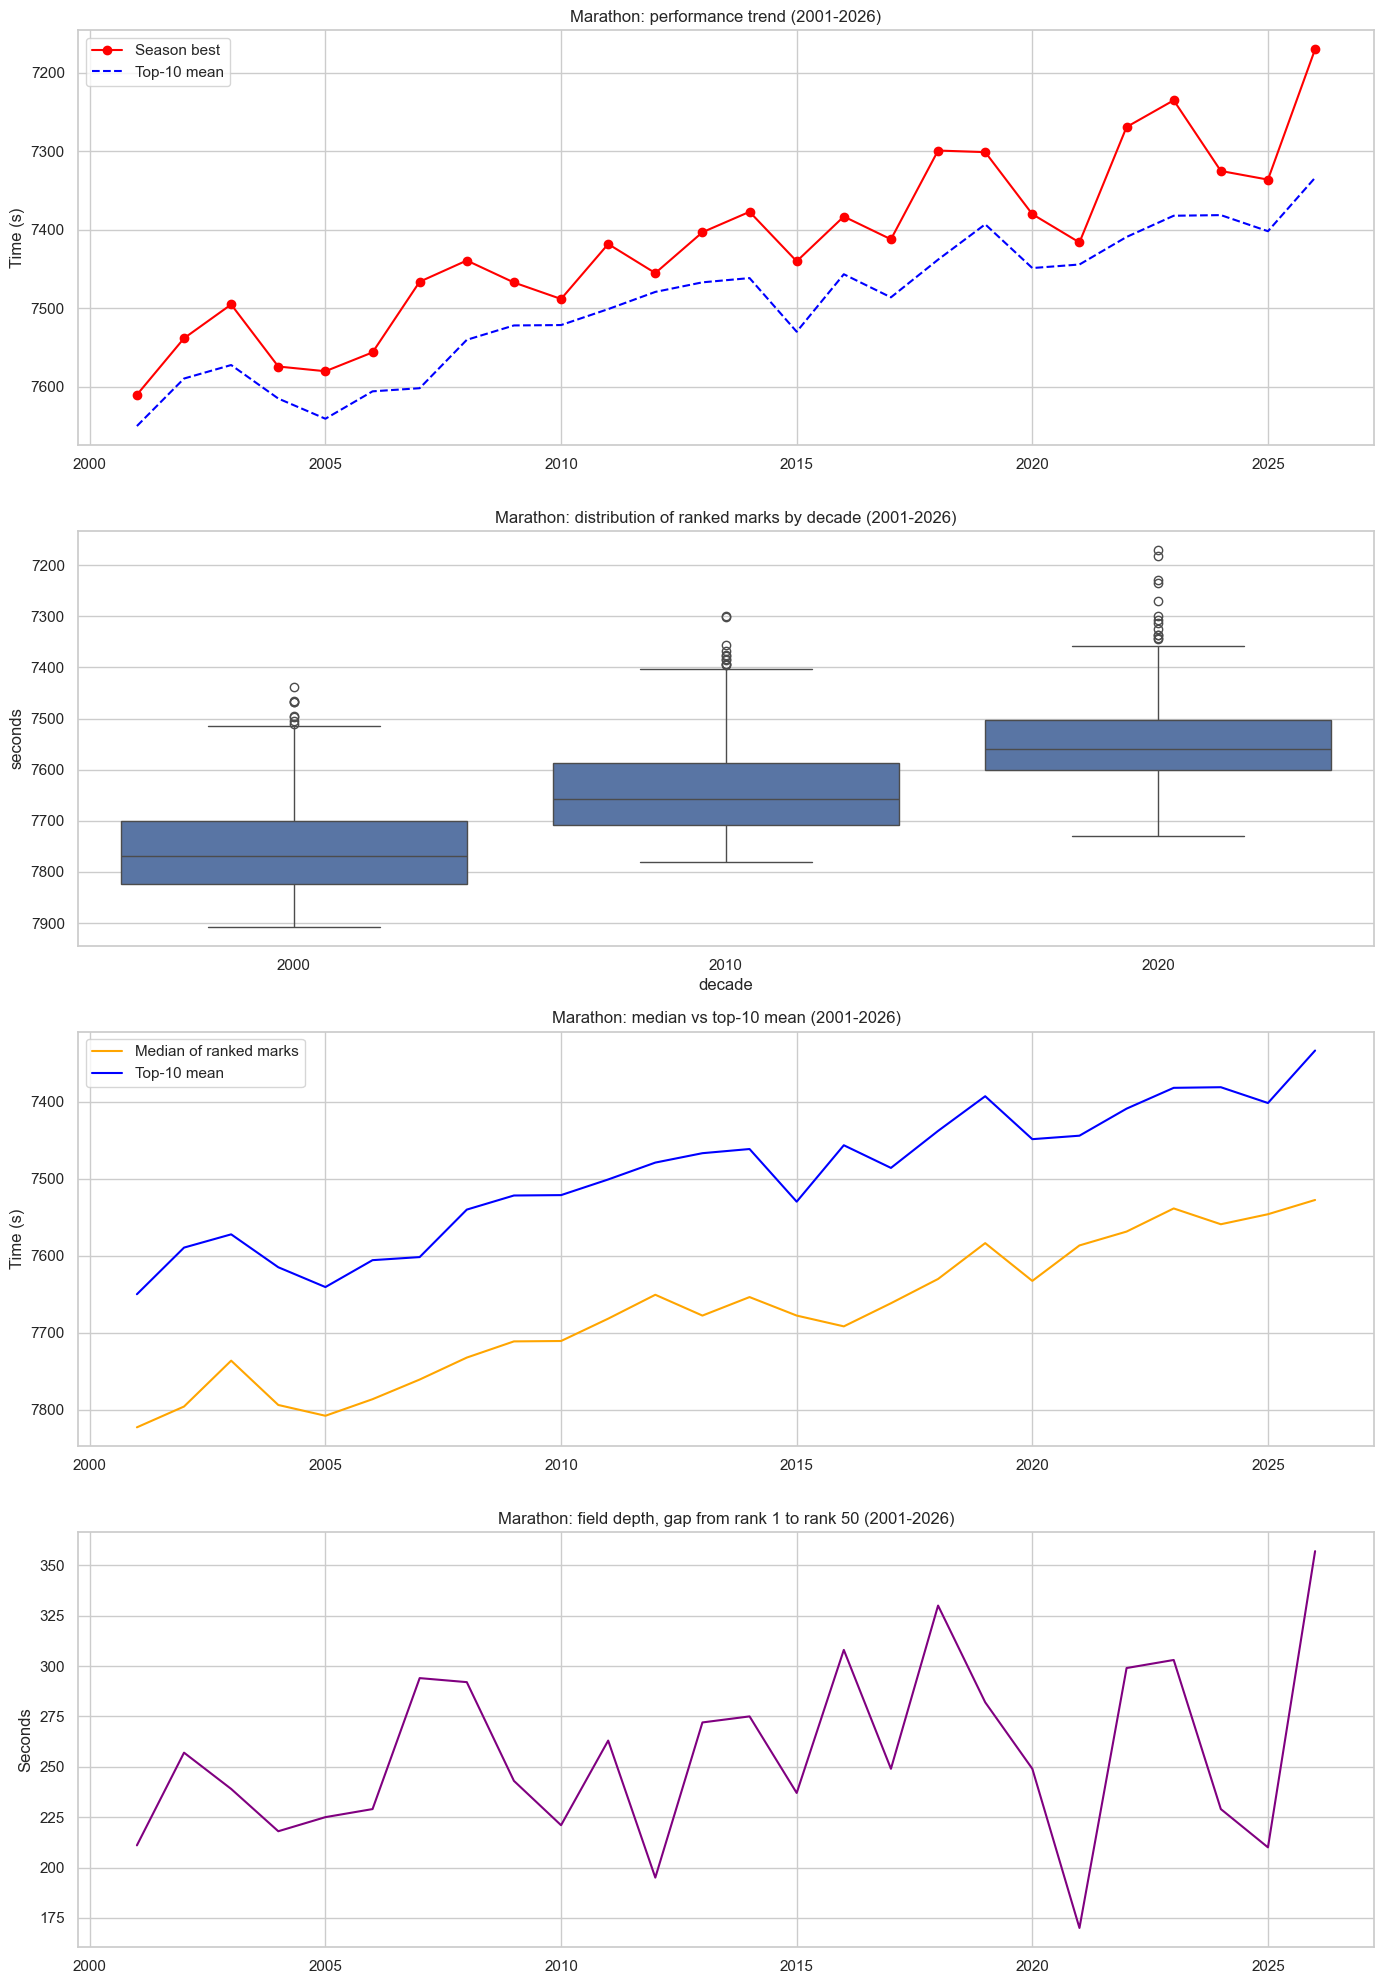

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20))

axes[0].plot(stats_df["year"], stats_df["best"], "o-", color="red", label="Season best")
axes[0].plot(stats_df["year"], stats_df["top_10_avg"], "--", color="blue", label="Top-10 mean")
axes[0].set_title(f"{EVENT}: performance trend ({SPAN})")
axes[0].invert_yaxis()
axes[0].set_ylabel("Time (s)")
axes[0].legend()

clean_df = clean_df.assign(decade=(clean_df["year"] // 10) * 10)
sns.boxplot(data=clean_df, x="decade", y="seconds", ax=axes[1])
axes[1].set_title(f"{EVENT}: distribution of ranked marks by decade ({SPAN})")
axes[1].invert_yaxis()

axes[2].plot(stats_df["year"], stats_df["median"], label="Median of ranked marks", color="orange")
axes[2].plot(stats_df["year"], stats_df["top_10_avg"], label="Top-10 mean", color="blue")
axes[2].set_title(f"{EVENT}: median vs top-10 mean ({SPAN})")
axes[2].invert_yaxis()
axes[2].set_ylabel("Time (s)")
axes[2].legend()

depth = clean_df.groupby("year")["seconds"].agg(lambda x: x.nsmallest(50).max() - x.min())
axes[3].plot(depth.index, depth.to_numpy(), color="purple")
axes[3].set_title(f"{EVENT}: field depth, gap from rank 1 to rank 50 ({SPAN})")
axes[3].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

## 3. Trend and anomalies

`calculate_improvement_rate` fits OLS to an extreme-value statistic, so treat the
slope as descriptive: its standard error and p-value are not interpretable as a
significance test. `detect_anomalies` uses a median/MAD robust z-score, so a single
large structural break does not inflate the scale it is tested against.

In [5]:
rate = engine.calculate_improvement_rate(stats_df)
depth_adjusted = engine.depth_adjusted_rate(stats_df)
baseline = AnalysisEngine.baseline_level(stats_df)
recent = AnalysisEngine.recent_level(stats_df)

print(f"Top-10 mean trend       : {rate:+.4f} s/year (descriptive only)")
print(f"  controlling for depth : {depth_adjusted['year']:+.4f} s/year")
print(f"Baseline (first 3 seasons): {S(baseline)}")
print(f"Recent   (last 3 seasons) : {S(recent)}")
print(f"Cumulative improvement    : {100 * (baseline - recent) / baseline:.2f}% over {SPAN}")
print(f"Anomalous seasons         : {engine.detect_anomalies(stats_df) or 'none'}")
print(f"World record              : {S(REAL_WR[EVENT])}")

Top-10 mean trend       : -10.8354 s/year (descriptive only)
  controlling for depth : -10.8354 s/year
Baseline (first 3 seasons): 2:06:43.73
Recent   (last 3 seasons) : 2:02:52.17
Cumulative improvement    : 3.05% over 2001-2026
Anomalous seasons         : [2015]
World record              : 1:59:30.00


## 4. Projection

Two fits are shown deliberately. The **logistic** fit is bounded below by the
assumed floor in `src/config.py`, so it cannot cross that floor -- any "tapering
towards the limit" it shows is the assumption, not a result. The **linear** fit
assumes no floor at all. The spread between them is the honest uncertainty about
the shape of the future, and it is usually much wider than the interval around
either one.

19:26:07 - cmdstanpy - INFO - Chain [1] start processing


19:26:10 - cmdstanpy - INFO - Chain [1] done processing


19:26:32 - cmdstanpy - INFO - Chain [1] start processing


19:26:33 - cmdstanpy - INFO - Chain [1] done processing


alpha=0.050 needs at least 19 calibration points, have 8; using the largest residual (coverage is not guaranteed).


alpha=0.050 needs at least 19 calibration points, have 8; using the largest residual (coverage is not guaranteed).


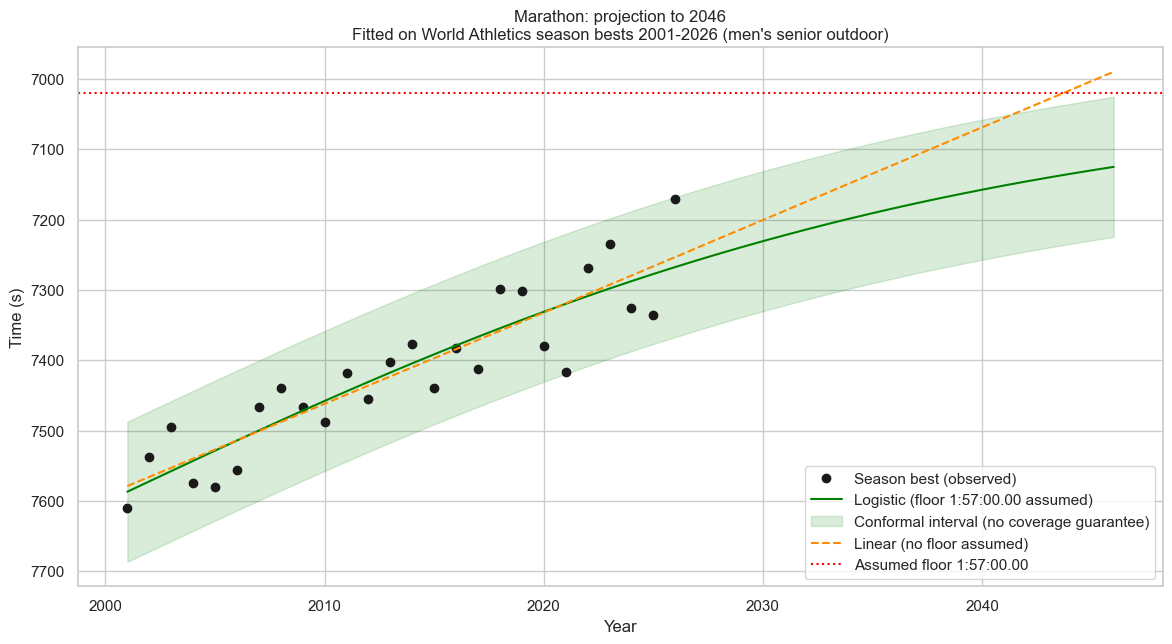

2046 logistic (assumes floor 1:57:00.00): 1:58:45.00
2046 linear   (no floor assumed)        : 1:56:29.72


In [6]:
floor = BIOLOGICAL_FLOORS[EVENT]

logistic = TrackForecaster(stats_df, cap=floor)
fc_log = logistic.forecast(target_year=PROJECTION_TARGET_YEAR)
fc_lin = TrackForecaster(stats_df, cap=None).forecast(target_year=PROJECTION_TARGET_YEAR)

log_years = pd.to_datetime(fc_log["ds"]).dt.year
lin_years = pd.to_datetime(fc_lin["ds"]).dt.year

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(stats_df["year"], stats_df["best"], "ko", label="Season best (observed)")
ax.plot(log_years, fc_log["yhat"], color="green", label=f"Logistic (floor {S(floor)} assumed)")
ax.fill_between(log_years, fc_log["yhat_lower"], fc_log["yhat_upper"], color="green", alpha=0.15,
                label="Conformal interval (no coverage guarantee)")
ax.plot(lin_years, fc_lin["yhat"], color="darkorange", linestyle="--", label="Linear (no floor assumed)")
ax.axhline(floor, color="red", linestyle=":", label=f"Assumed floor {S(floor)}")
ax.set_title(f"{EVENT}: projection to {PROJECTION_TARGET_YEAR}\n"
             f"Fitted on World Athletics season bests {SPAN} (men's senior outdoor)")
ax.set_xlabel("Year")
ax.set_ylabel("Time (s)")
ax.invert_yaxis()
ax.legend()
plt.show()

print(f"{PROJECTION_TARGET_YEAR} logistic (assumes floor {S(floor)}): {S(fc_log.iloc[-1]['yhat'])}")
print(f"{PROJECTION_TARGET_YEAR} linear   (no floor assumed)        : {S(fc_lin.iloc[-1]['yhat'])}")

### Floor sensitivity

How much does the horizon value move when the assumed floor moves +/-10%? If this
spread is large relative to the projected improvement, the projection is mostly
reporting the assumption back.

In [7]:
sensitivity = logistic.floor_sensitivity(PROJECTION_TARGET_YEAR)
for label, value in sensitivity.items():
    print(f"{label:<20} {S(value)}")

values = list(sensitivity.values())
print(f"\nSpread across floor assumptions: {max(values) - min(values):.2f} s")

alpha=0.050 needs at least 19 calibration points, have 8; using the largest residual (coverage is not guaranteed).


alpha=0.050 needs at least 19 calibration points, have 8; using the largest residual (coverage is not guaranteed).


alpha=0.050 needs at least 19 calibration points, have 8; using the largest residual (coverage is not guaranteed).


floor_sensitivity variant floor_plus_10pct failed: cap must be greater than floor (which defaults to 0).


no_floor             1:56:29.72
floor_minus_10pct    1:57:35.62
floor                1:58:45.00

Spread across floor assumptions: 135.28 s
